In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, Normalizer
from sklearn.pipeline import Pipeline

In [2]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

In [3]:
df_test = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_testing-set.csv")
df_train = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_training-set.csv")

In [4]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['sbytes', 'sttl', 'sload', 'tcprtt', 'smean', 'ct_srv_src', 'ct_state_ttl', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'service', 'label']

df_test = df_test[df_test.columns.intersection(keep_cols)]
df_train = df_train[df_train.columns.intersection(keep_cols)]

In [5]:
df_train['label'].value_counts()
df_test['label'].value_counts()

label
1    45332
0    37000
Name: count, dtype: int64

In [6]:
normal = df_train.query('label == 0').sample(56000)
attack = df_train.query('label == 1').sample(1000)
df_train_reduced = pd.concat([normal, attack]).sample(frac=1)

normal = df_test.query('label == 0').sample(37000)
attack = df_test.query('label == 1').sample(1000)
df_test_reduced = pd.concat([normal, attack]).sample(frac=1)

In [7]:
y_train = df_train_reduced['label']
x_train = df_train_reduced.drop("label", axis=1)

y_test = df_test_reduced['label']
x_test = df_test_reduced.drop("label", axis=1)

In [8]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [9]:
print(x_test.shape)
print(x_train.shape)

(38000, 11)
(45600, 11)


In [10]:
# encoding features which have data type as object and normalizing and normalizing numerical ones in specified interval

x_train = encode_objects(x_train)
x_val = encode_objects(x_val)
x_test = encode_objects(x_test)

In [11]:
scaler = StandardScaler()

In [12]:
scaler.fit(x_train)

StandardScaler()

In [13]:
x_train_transformed = scaler.transform(x_train)
x_val_transformed = scaler.transform(x_val)

In [14]:
# Load the extension and start TensorBoard
%load_ext tensorboard
%tensorboard --logdir logs/autoencoder_unsw/

Reusing TensorBoard on port 6006 (pid 20796), started 9:50:23 ago. (Use '!kill 20796' to kill it.)

In [15]:
# data dimensions // hyperparameters 
input_dim = x_train_transformed.shape[1]
BATCH_SIZE = 64
EPOCHS = 100

# https://keras.io/layers/core/
autoencoder = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Input(shape=(input_dim,)), 
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(2, activation='relu'),
    
    # reconstruction / decode
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(input_dim, activation='relu')
    
])

# https://keras.io/api/models/model_training_apis/
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.14 KB)

 Trainable params: 293 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/autoencoder_unsw_best_weights.keras', 
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/autoencoder_unsw/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

In [17]:
history = autoencoder.fit(
    x_train_transformed, x_train_transformed,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_val_transformed, x_val_transformed)
)

Epoch 1/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.1504 - loss: 0.8342 - val_acc: 0.3404 - val_loss: 0.9048
Epoch 2/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4635 - loss: 0.6089 - val_acc: 0.3576 - val_loss: 0.8693
Epoch 3/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4938 - loss: 0.6092 - val_acc: 0.3671 - val_loss: 0.8394
Epoch 4/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4895 - loss: 0.5297 - val_acc: 0.3654 - val_loss: 0.8256
Epoch 5/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4886 - loss: 0.5347 - val_acc: 0.3661 - val_loss: 0.8119
Epoch 6/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4870 - loss: 0.5650 - val_acc: 0.3661 - val_loss: 0.8039
Epoch 7/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4909 - loss: 0.5111 - val_acc: 0.3702 - val_loss: 0.7960
Epoch 8/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4922 - loss: 0.5711 - val_acc: 0.3795 - val_loss: 0.7883
Epoch 9/100
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

In [18]:
x_test_transformed = scaler.transform(x_test)

reconstructions = autoencoder.predict(x_test_transformed)

1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step


In [19]:
mse = np.mean(np.power(x_test_transformed - reconstructions, 2), axis=1)

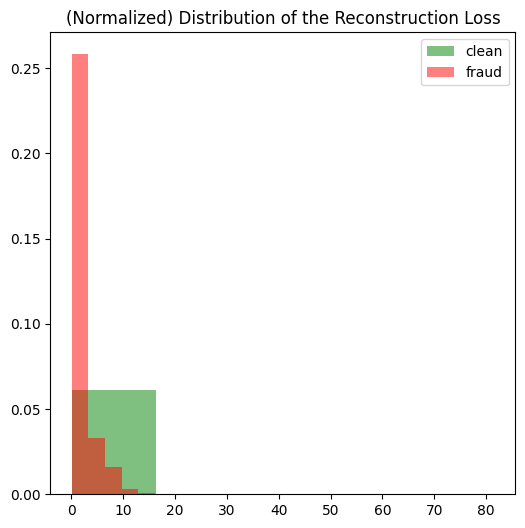

In [20]:
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

In [24]:
def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

In [31]:
# Calculate the reconstruction error on the validation set
reconstructions_val = autoencoder.predict(x_val_transformed)
mse_val = np.mean(np.power(x_val_transformed - reconstructions_val, 2), axis=1)

# Calculate the MAD scores for the validation set
z_scores_val = mad_score(mse_val)

# Calculate the precision and recall for a range of threshold values
precisions, recalls, thresholds = precision_recall_curve(y_val, z_scores_val)

# Calculate the F1 score for each threshold
f1_scores = 2*recalls*precisions/(recalls+precisions)

# Get the threshold that gives the highest F1 score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print("Threshold that maximizes F1 score on validation data:", optimal_threshold)

357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
Threshold that maximizes F1 score on validation data: 19.18615720992092


In [29]:
THRESHOLD = 19.18

z_scores = mad_score(mse)
outliers = z_scores > THRESHOLD


F1 Score: 0.20080971659919028
Precision: 0.16870748299319727
Recall: 0.248
Accuracy: 0.9480526315789474


Text(50.722222222222214, 0.5, 'True Label')

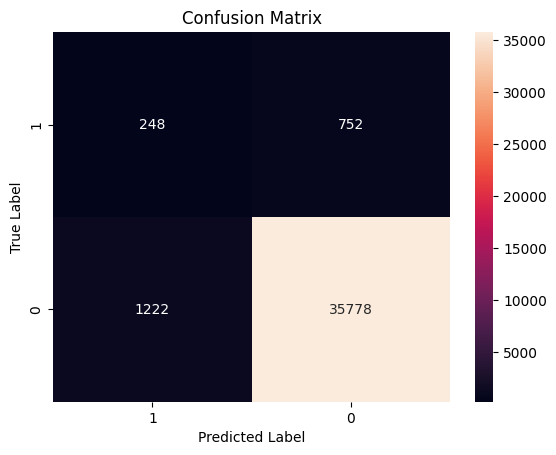

In [30]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

f1_test = f1_score(y_test, outliers)
precision_test = precision_score(y_test, outliers)
recall_test = recall_score(y_test, outliers)
accuracy_test = accuracy_score(y_test, outliers)

print(f"F1 Score: {f1_test}\nPrecision: {precision_test}\nRecall: {recall_test}\nAccuracy: {accuracy_test}")

cm = confusion_matrix(y_test, outliers)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [23]:
tn, fp, fn, tp = cm.ravel()
print("False Negative Rate:", fn/(fn+tn))
print("False Positive Rate:", fp/(fp+tp))

False Negative Rate: 0.01528866559833687
False Positive Rate: 0.9566092146737308
